## Testing for the environmental dependence 

* Import the shear catalogs -- (DECADE, DECALS, SDSS)
* Build an environmental driver around the SDSS selected clusters.
* Bin the richness by different environmental drivers.

### Benchmark testing
What is a bare-bones test. Construct with sparsely sampled BCG galaxies around DESI clusters the lens sample. Construct a sparsely populated source sample with the DECADE survey. 

No correction terms (e.g. multiplative bias). No random injections. Just a barebones version. 

* Correct IIP Weighting
* Correct for shear biases.
* Correct for boost factor using random catalog


In [4]:
from scipy.stats import kde
import h5py
import astropy.io.fits as fits
import csv
import pandas as pd
import numpy as np
import tables
import pickle
import os
from astropy.table import Table
from astropy.coordinates import SkyCoord
from tqdm import tqdm
from astropy.io import ascii
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import incredible as cr
from scipy.special import erf
from scipy import stats
import scipy.optimize as opt
from scipy import stats
import scipy.optimize as opt
import emcee
import tqdm
import pickle
from astropy import table
from astropy.table import Table, join, unique
from specutils import SpectralRegion
from scipy.interpolate import BSpline, make_interp_spline, UnivariateSpline

from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d
import numpy as np
import astropy.units as u
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18
from astropy.cosmology import z_at_value
cosmo = Planck18

## Functions for computing spectroscopic richness and profiles
from projection_functions import *


##Plotting
import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt

plot_params = {

'axes.linewidth': 1.25,
'xtick.major.width': 1, 'ytick.major.width': 1,
'xtick.minor.width': 1, 'ytick.minor.width': 1,
'xtick.major.size': 12, 'ytick.major.size': 12,
'xtick.labelsize': 12, 'ytick.labelsize': 12,
'xtick.direction': 'in', 'ytick.direction': 'in',
'xtick.major.pad': 6, 'xtick.minor.pad': 6,
'figure.constrained_layout.use': True,
#'text.usetex': True,
'font.family': 'Serif',
'font.size': 14,
'legend.fontsize': 11
    
}
plt.rcParams.update(plot_params)

## Importing the Catalogs

### DECADE Shear

In [5]:
decade_dir = '/pscratch/sd/z/zzhang13/DECADE/'
desi_dir = '/pscratch/sd/z/zzhang13/DESI/'
decade_shear = 'decade_nsgc_dsigmaver.hdf5'
f = h5py.File(decade_dir + decade_shear, 'r+')
list(f.keys())

['__astropy_table__', 'redshift']

In [6]:
dset = f['__astropy_table__'] ##Sparse sampling
names = dset.dtype.names
sparse_ind = 10
dset = dset[::sparse_ind]
nz = np.array(f['redshift']) ##number density per bin
dset_tab = Table(dset, names=names) ##This is memory intensive. Sparsely sample before running this code. 
nz_tab = Table(nz)

table_s = dset_tab
table_l = table_s['ra','dec','z','w']
table_l.rename_column('w', 'w_sys')

### DESI BGS

In [7]:
with open('bgs_clus_RM_gal_matched.pickle', 'rb') as handle:
    bgs_matched = pickle.load(handle)
bgs_matched.columns

## Redshift cut to remove projection
zcut = np.abs((bgs_matched['Z_BGS'] - bgs_matched['Z_SPEC_x']))/(1+bgs_matched['Z_BGS']) <= 0.1
bgs_matched = bgs_matched[zcut]

##Cl center catalog
sparse_ind = 10
cl_center = bgs_matched[['ID','RA_x', 'DEC_x', 'Z_SPEC_x']][::sparse_ind]
cl_center.rename_columns(['RA_x', 'DEC_x', 'Z_SPEC_x'],['ra', 'dec', 'z'])

##BGS catalog
bgs_coord = bgs_matched['ID','RA_BGS', 'DEC_BGS', 'Z_BGS', 'WEIGHT']
bgs_coord.rename_columns(['RA_BGS', 'DEC_BGS', 'Z_BGS', 'WEIGHT'],['ra', 'dec', 'z', 'w_sys'])

##Make all galaxy weights the same.
#bgs_coord['w_sys'] = 1

### Random Catalog

In [8]:
numRand = 1 ##Total of 18
desiDir = '/global/cfs/cdirs/desi/survey/catalogs/dr1/LSS/iron/LSScats/v1.5pip/'
for i in range(numRand):
    randomCat = "BGS_ANY_{}_full_HPmapcut.ran.fits".format(i)
    print(randomCat)
    table_r = Table.read(desiDir + randomCat)

BGS_ANY_0_full_HPmapcut.ran.fits


In [9]:
table_r = table_r[::1000]

In [10]:
len(table_r)

18682

In [11]:
table_r = table_r['RA','DEC']
table_r.rename_columns(['RA', 'DEC'],['ra', 'dec'])

for name in table_r.colnames:
    table_r[name] = table_r[name].value  # strip units
    table_r[name].unit = None

In [12]:
## Pseudo redshift
table_r['z'] = np.random.normal(0.25, 0.1, len(table_r))
##Remove bad redshifts
mask = np.where(table_r['z'] > 0)
table_r = table_r[mask]

table_r['w_sys'] = 1

## Diagnostic plots

### Source galaxy catalog

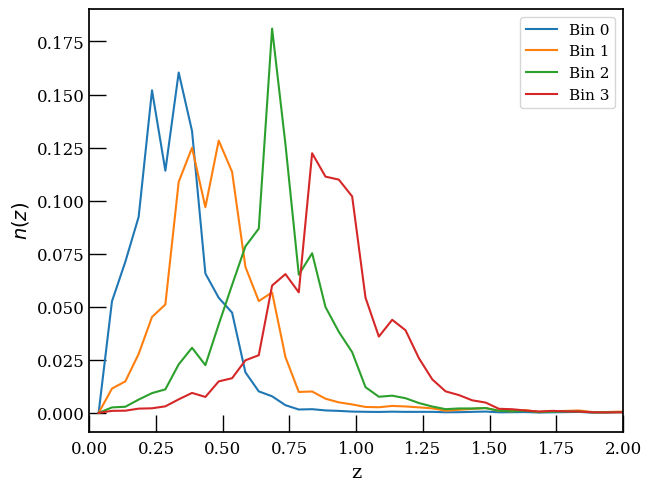

In [13]:
## What is n(z) for each bin. 
plt.plot(nz_tab['z'],nz_tab['n'][:,0], label='Bin 0')
plt.plot(nz_tab['z'],nz_tab['n'][:,1], label='Bin 1')
plt.plot(nz_tab['z'],nz_tab['n'][:,2], label='Bin 2')
plt.plot(nz_tab['z'],nz_tab['n'][:,3], label='Bin 3')
plt.xlim([0,2])
plt.ylabel(r'$n(z)$')
plt.xlabel('z')
plt.legend()
plt.show()

### Lens galaxy catalog

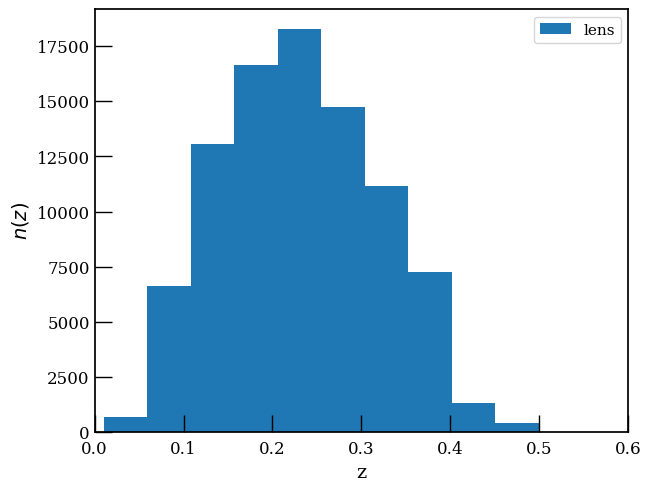

In [14]:
## What is n(z) for each bin. 
plt.hist(bgs_coord['z'], label='lens')
plt.xlim([0,0.6])
plt.ylabel(r'$n(z)$')
plt.xlabel('z')
plt.legend()
plt.show()

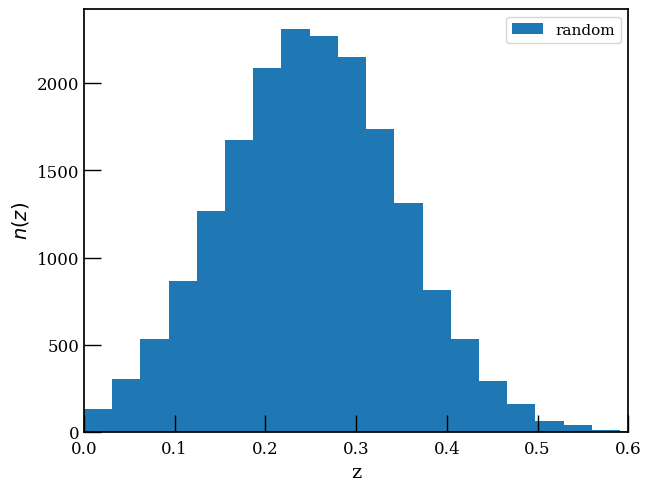

In [15]:
## What is n(z) for each bin. 
plt.hist(table_r['z'], label='random', bins=20)
plt.xlim([0,0.6])
plt.ylabel(r'$n(z)$')
plt.xlabel('z')
plt.legend()
plt.show()

## Find DESI lenses and matched sources

* Find BCG galaxies in the DR1 sample around the clusters (make a pipeline for matching)
* Find an overlap region between DESI lenses and DECADE sources.
* Enforce redshift contamination limit.
* Inject randoms into lens. 

In [16]:
from matchCatalogs import matchCatalogs_2D_angular, matchCatalogs_2D_physical
import astropy.units as u
from astropy.coordinates import SkyCoord
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18

In [17]:
import time
from functools import wraps

def timing(func):
    """Decorator that measures execution time of a function."""
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()
        print(f"{func.__name__} took {end - start:.6f} seconds")
        return result
    return wrapper


In [18]:
@timing
def matchCatalogs_2D_angular(catalog1, catalog2, max_sep):
    coord1 = SkyCoord(ra=catalog1['ra']*u.degree, dec=catalog1['dec']*u.degree, distance = 1*u.Mpc)
    coord2 = SkyCoord(ra=catalog2['ra']*u.degree, dec=catalog2['dec']*u.degree, distance = 1*u.Mpc)
    
    idxc, idxcatalog, d2d, d3d = coord1.search_around_sky(coord2, max_sep)

    catalog1_matched = catalog1[idxcatalog]
    catalog2_matched = catalog2[idxc]

    ## Warnings for edge cases
    if not np.all(d2d < max_sep):
        warnings.warn("Max separation larger than imposed limit", RuntimeWarning)
    if len(idxc) == 0 :
        warnings.warn("No matches were found", RuntimeWarning)
    
    return idxcatalog, idxc, catalog1_matched, catalog2_matched

@timing
def matchCatalogs_2D_physical(catalog1, catalog2, max_sep):

    ##First circle galaxies within some angular separation. 
    ##This narrows the search. This part of the algorithm can be optimized.
    z_min = np.min(catalog2['z']*cu.redshift)
    D_A = Planck18.angular_diameter_distance(z_min)
    max_angular_sep = (max_sep/ D_A)*u.rad
    _, _, catalog1_matched, catalog2_matched = \
        matchCatalogs_2D_angular(catalog1, catalog2, max_angular_sep)

    ##Compute the distance to the catalog2
    redshift2 = catalog2_matched['z'] * cu.redshift
    distance2 = redshift2.to(u.Mpc, cu.redshift_distance(Planck18, kind="comoving")) #Units of Mpc/h
    
    #Build coordinates
    coord1 = SkyCoord(ra=catalog1_matched['ra']*u.degree, dec=catalog1_matched['dec']*u.degree, distance = distance2)
    coord2 = SkyCoord(ra=catalog2_matched['ra']*u.degree, dec=catalog2_matched['dec']*u.degree, distance = distance2)

    ## Search around candidates
    idxc, idxcatalog, d2d, d3d = coord1.search_around_3d(coord2, max_sep)
    catalog1_matched = catalog1_matched[idxcatalog]
    catalog2_matched = catalog2_matched[idxc]

    ## Warnings for edge cases
    if not np.all(d3d < max_sep):
        warnings.warn("Max separation larger than imposed limit", RuntimeWarning)
    if len(idxc) == 0 :
        warnings.warn("No matches were found", RuntimeWarning)
    
    return idxcatalog, idxc, catalog1_matched, catalog2_matched

In [19]:
def haversine(lon1, lat1, lon2, lat2, r=1):
    """
    Calculate the great circle distance between two points.
    """
    # convert decimal degrees to radians 
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a)) 
    return c*r

In [20]:
max_sep = 2.2 * u.degree ## For a z=0.1 at Planck18 object has equiv of 2.2 degree sep. for 15 Mpc/h
idx1, idx2, table_s_matched, cl_center_matched = matchCatalogs_2D_angular(table_s, cl_center, max_sep)

matchCatalogs_2D_angular took 92.195820 seconds


2.1999999598395004


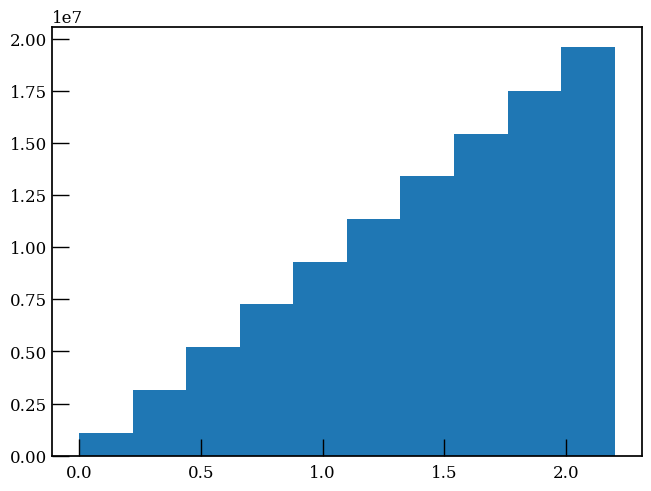

In [21]:
rad2deg = 180 / np.pi
distance = rad2deg * haversine(table_s_matched['ra'], table_s_matched['dec'], cl_center_matched['ra'], cl_center_matched['dec'])
print(np.max(distance))
plt.hist(distance)
plt.show()

In [22]:
## We only take the unique values of lenses, sources and galaxy clusters
idx1_unique = np.unique(idx1); 
idx2_unique = np.unique(idx2)
table_l = table_l[idx1_unique]
table_s = table_s[idx1_unique]
cl_center = cl_center[idx2_unique]

##Find BGS around clusters in the DECADE survey
print(len(bgs_matched))
mask = np.isin(bgs_coord['ID'], cl_center['ID'])
bgs_matched = bgs_coord[mask]
print(len(bgs_matched))


90158
44083


## Converting from gamma to DS using the dSigma procedure. 
https://dsigma.readthedocs.io/en/latest/applications/des_y3.html

First do a bare-bones version with no random injection. Sparse sampling with 1:10 lenses and 1:10 clusters.

In [35]:
table_s

ra,dec,z_bin,e_1,e_2,w,z,R11_gamma,R22_gamma,R11_sel,R22_sel,R_11,R_22,sky,m,R_12,R_21
float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes3,float64,float64,float64
334.004855,-6.770244,3,0.10798306334983081,0.07982373820802668,10.274507154623281,0.803,0.5938664161113472,0.5949339965243698,0.03146408125781018,0.03306958203605394,0.6253304973691574,0.6280035785604238,SGC,-0.0572,0.0,0.0
334.160713,-6.780533,0,0.0476212714841502,0.1137278776544679,10.177321035118753,0.0,0.8539544602941103,0.8547116444057735,-0.010479494142593984,-0.01086324829891928,0.8434749661515163,0.8438483961068542,SGC,-0.013300000000000001,0.0,0.0
333.935438,-6.782788,0,-0.13452669012360796,0.21597827178232704,14.945526060347706,0.0,0.8539544602941103,0.8547116444057735,-0.010479494142593984,-0.01086324829891928,0.8434749661515163,0.8438483961068542,SGC,-0.013300000000000001,0.0,0.0
333.968535,-6.772238,0,-0.05893781885393293,-0.0822042309267119,11.586936292235851,0.0,0.8539544602941103,0.8547116444057735,-0.010479494142593984,-0.01086324829891928,0.8434749661515163,0.8438483961068542,SGC,-0.013300000000000001,0.0,0.0
333.763282,-6.78083,0,-0.062115748832536136,0.06594678037888796,10.468266230810364,0.0,0.8539544602941103,0.8547116444057735,-0.010479494142593984,-0.01086324829891928,0.8434749661515163,0.8438483961068542,SGC,-0.013300000000000001,0.0,0.0
333.754828,-6.769559,1,-0.18818921417166684,-0.06889675455435046,8.444303675350032,0.381,0.7609073691643077,0.7619076719984976,0.0172341298348247,0.01655025799621635,0.7781414989991324,0.778457929994714,SGC,-0.0226,0.0,0.0
333.90457,-6.781347,2,-0.1628836803893637,-0.22070634633409714,20.913434756661566,0.619,0.7234991800497551,0.7245631997096869,0.024151115540951708,0.023880637267742262,0.7476502955907068,0.7484438369774291,SGC,-0.0367,0.0,0.0
334.167123,-6.77119,3,0.06580611618454557,0.048722720035599555,8.542453445451546,0.803,0.5938664161113472,0.5949339965243698,0.03146408125781018,0.03306958203605394,0.6253304973691574,0.6280035785604238,SGC,-0.0572,0.0,0.0
334.154709,-6.76791,0,0.1647015097143231,-0.4336240670140675,10.16178754524472,0.0,0.8539544602941103,0.8547116444057735,-0.010479494142593984,-0.01086324829891928,0.8434749661515163,0.8438483961068542,SGC,-0.013300000000000001,0.0,0.0


In [23]:
## First need to convert these into \Delta\Sigma. 
## Testing with the lens, source pair (1,2) first then iterate over all the bins. 

from astropy.cosmology import Planck18
from dsigma.precompute import precompute

rp_bins = np.logspace(-0.5, 1, 15) #From 1 to 15 Mpc/h
precompute(bgs_matched, table_s, rp_bins, cosmology=Planck18, comoving=True, table_n = nz_tab,
           lens_source_cut=0.1, progress_bar=True, n_jobs=4)
bgs_matched[0:5]

100%|██████████| 5195/5195 [00:03<00:00, 1600.89it/s]


ID,ra,dec,z,w_sys,sum 1,sum w_ls,sum w_ls e_t,sum w_ls z_s,sum w_ls e_t sigma_crit,sum w_ls sigma_crit,sum w_ls m,sum w_ls R_T,sum w_ls z_l
int32,float64,float64,float64,float64,int64[14],float64[14],float64[14],float64[14],float64[14],float64[14],float64[14],float64[14],float64[14]
24,203.40740192834184,20.240632324271928,0.09208616645492462,1.006801724433899,4 .. 2517,2.2067281423319562e-06 .. 0.0012664543740537296,7.17721532651084e-08 .. -1.2774476299906653e-06,1.7264437808271653e-06 .. 0.0008762452209943396,0.00031435339922523253 .. -0.004386062786409581,0.01000921439032042 .. 5.977615073963562,-8.606387929886068e-08 .. -4.045839650261956e-05,1.5366712806130774e-06 .. 0.0009099173768544941,2.032091350355471e-07 .. 0.00011662292829667912
24,203.38847171227926,20.32447290206338,0.17285315392170078,4.0,0 .. 627,0.0 .. 0.0008302471480183734,0.0 .. -5.806948889468475e-06,0.0 .. 0.0005933278031351766,0.0 .. -0.01826389502507228,0.0 .. 2.418508919940112,0.0 .. -2.8038005642030508e-05,0.0 .. 0.0005920491325092549,0.0 .. 0.000143510838069473
24,203.5526810077473,20.30655343286654,0.11872654163983234,10.0,3 .. 1474,1.9439667013139576e-06 .. 0.0011282437419883867,-1.704527895031515e-07 .. 7.0250256821360355e-06,1.07669066045679e-06 .. 0.0007977422705777159,-0.0007022132456874755 .. 0.02490703308811897,0.008014617181440167 .. 4.313953778593685,-4.682920265809896e-08 .. -3.6911610369871256e-05,1.4855172826931368e-06 .. 0.0008046319768825473,2.3080044350999911e-07 .. 0.00013395247761306445
24,203.5430187293466,20.251720139768107,0.2101704761820765,25.0,0 .. 440,0.0 .. 0.000734988712953979,0.0 .. -8.292099129816976e-06,0.0 .. 0.0005276814941321895,0.0 .. -0.022988340639456487,0.0 .. 1.9175441226442336,0.0 .. -2.4792899105189994e-05,0.0 .. 0.0005226158445779106,0.0 .. 0.0001544729277899893
24,203.46368126161514,20.40778742419952,0.14418524665420862,1.0,2 .. 979,3.3833147217505904e-06 .. 0.0009915584572426734,2.8336192106514888e-08 .. 5.488763294295761e-06,2.7416735757796654e-06 .. 0.0007047745957941153,0.00011493474753820302 .. 0.014907444405846187,0.010451090647166029 .. 3.2783119218641166,-1.3067211087110183e-07 .. -3.260731204522535e-05,2.2971313129493364e-06 .. 0.0007057760317301624,4.87824067664424e-07 .. 0.00014296810072960144


In [24]:
precompute(table_r, table_s, rp_bins, cosmology=Planck18, comoving=True, table_n = nz_tab,
           lens_source_cut=0.1, progress_bar=True, n_jobs=4)
table_r[0:5]

100%|██████████| 18267/18267 [00:02<00:00, 8781.15it/s] 


ra,dec,z,w_sys,sum 1,sum w_ls,sum w_ls e_t,sum w_ls z_s,sum w_ls e_t sigma_crit,sum w_ls sigma_crit,sum w_ls m,sum w_ls R_T,sum w_ls z_l
float64,float64,float64,int64,int64[14],float64[14],float64[14],float64[14],float64[14],float64[14],float64[14],float64[14],float64[14]
11.191156277184763,-19.379551007429864,0.2667415839601946,1,0 .. 0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0
22.19891633501846,-19.212116810433358,0.18635007841176027,1,0 .. 0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0
61.50321035663282,-19.248142713209123,0.018190257306525237,1,0 .. 0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0
11.099963911775367,-18.890452916758974,0.26800220668093133,1,0 .. 0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0
22.078416773517844,-18.936869300371953,0.2274369655820027,1,0 .. 0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0


In [25]:
from dsigma.jackknife import compute_jackknife_fields, jackknife_resampling
from dsigma.stacking import excess_surface_density

# Drop all lenses and randoms that did not have any nearby source.
print("Match ratio: ", len(np.where(np.sum(bgs_matched['sum 1'], axis=1) > 0)[0])/len(bgs_matched))
bgs_matched = bgs_matched[np.sum(bgs_matched['sum 1'], axis=1) > 0]
print(len(bgs_matched))

Match ratio:  0.9066760429190391
39969


In [26]:
correction_dict = {'no_correction':{'scalar_shear_response_correction':False, 'matrix_shear_response_correction':False, 'selection_bias_correction':False, 'random_subtraction':False}, \
                   'multiplicative':{'scalar_shear_response_correction':True, 'matrix_shear_response_correction':True, 'selection_bias_correction':False, 'random_subtraction':False}, \
                  'multiplicative+boost':{'scalar_shear_response_correction':True, 'matrix_shear_response_correction':True, 'selection_bias_correction':False, 'random_subtraction':True} }

In [27]:
for key, val in correction_dict.items():
    print(val)

{'scalar_shear_response_correction': False, 'matrix_shear_response_correction': False, 'selection_bias_correction': False, 'random_subtraction': False}
{'scalar_shear_response_correction': True, 'matrix_shear_response_correction': True, 'selection_bias_correction': False, 'random_subtraction': False}
{'scalar_shear_response_correction': True, 'matrix_shear_response_correction': True, 'selection_bias_correction': False, 'random_subtraction': True}


In [28]:
table_l = bgs_matched
centers = compute_jackknife_fields(
    table_l, 100, distance_threshold = 2, weights=np.sum(table_l['sum 1'], axis=1))
compute_jackknife_fields(table_r, centers)

##chunk the data for more efficient memory storage
## Turn this into a dictionary or a record array. 
ds_dict = {} 
z_bins = np.array([0.0, 0.2, 0.5])


for lens_bin in range(len(z_bins) - 1):
    for key, val in correction_dict.items():
            scalar_shear_response_correction = val['scalar_shear_response_correction']
            matrix_shear_response_correction = val['matrix_shear_response_correction']
            selection_bias_correction = val['selection_bias_correction']
            random_subtraction = val['random_subtraction']
        
            mask_l = ((z_bins[lens_bin] <= table_l['z']) &
                      (table_l['z'] < z_bins[lens_bin + 1]))

            mask_r = ((z_bins[lens_bin] <= table_r['z']) &
              (table_r['z'] < z_bins[lens_bin + 1]))
        
            kwargs = dict(return_table=True, scalar_shear_response_correction=scalar_shear_response_correction,
                          matrix_shear_response_correction=matrix_shear_response_correction,
                          selection_bias_correction=selection_bias_correction,
                          random_subtraction=random_subtraction, table_r=table_r[mask_r])
        
            result = excess_surface_density(table_l[mask_l], **kwargs)
            kwargs['return_table'] = False
            result['ds_err'] = np.sqrt(np.diag(jackknife_resampling(
                excess_surface_density, table_l[mask_l], **kwargs)))
            label = key + ' ' + f'lens_bin:{z_bins[lens_bin]}-{z_bins[lens_bin+1]}'
            print(label, len(table_l[mask_l]))
            ds_dict[label] = result
        #result.write(f'des_{lens_bin}.csv', overwrite=True)

no_correction lens_bin:0.0-0.2 16531
multiplicative lens_bin:0.0-0.2 16531
multiplicative+boost lens_bin:0.0-0.2 16531
no_correction lens_bin:0.2-0.5 23438
multiplicative lens_bin:0.2-0.5 23438
multiplicative+boost lens_bin:0.2-0.5 23438


In [29]:
colors = plt.cm.tab10.colors   # 10-color palette
linestyles = ['-', '--', '-.'] # 3 styles

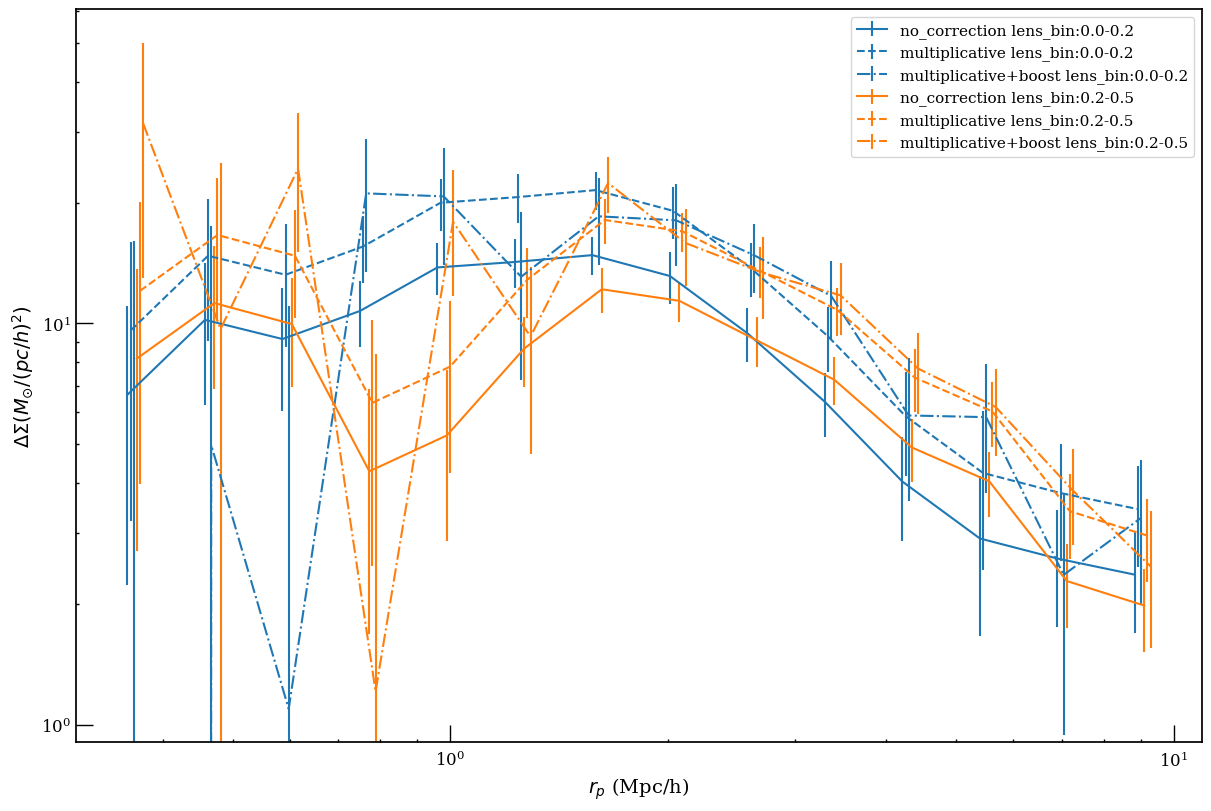

In [30]:
plt.figure(figsize=(12,8))
shift = 1
i=0
for key, result in ds_dict.items():
    color = colors[i // 3 % len(colors)] 
    style = linestyles[i % 3]  
    plt.errorbar(result['rp']*shift, result['ds'], yerr=result['ds_err'], label=key, color=color, linestyle=style)
    shift *= 1.01
    i+=1

plt.yscale('log')
plt.xscale('log')
#plt.xlim([1,15])
plt.ylabel(r'$\Delta\Sigma (M_{\odot}/(pc/h)^2)$')
plt.xlabel(r'$r_p$ (Mpc/h)')
plt.legend()
plt.show()

In [31]:
table_l_iipweight = bgs_matched
table_l_noiip = table_l_iipweight.copy()
table_l_noiip['w_sys'] = 1
correction_dict = {'with IIP': table_l_iipweight, 'no IIP': table_l_noiip}

In [32]:
## Do with and without PIP weighting

centers = compute_jackknife_fields(
    table_l, 100, distance_threshold = 2, weights=np.sum(table_l['sum 1'], axis=1))
compute_jackknife_fields(table_r, centers)

##chunk the data for more efficient memory storage
## Turn this into a dictionary or a record array. 
ds_dict = {} 
z_bins = np.array([0.0, 0.2, 0.5])

for lens_bin in range(len(z_bins) - 1):
    for key, val in correction_dict.items():
            table_l = val
            scalar_shear_response_correction = True
            matrix_shear_response_correction = True
            selection_bias_correction = False
            random_subtraction = True
        
            mask_l = ((z_bins[lens_bin] <= table_l['z']) &
                      (table_l['z'] < z_bins[lens_bin + 1]))
            mask_r = ((z_bins[lens_bin] <= table_r['z']) &
              (table_r['z'] < z_bins[lens_bin + 1]))
        
            kwargs = dict(return_table=True, scalar_shear_response_correction=scalar_shear_response_correction,
                          matrix_shear_response_correction=matrix_shear_response_correction,
                          selection_bias_correction=selection_bias_correction,
                          random_subtraction=random_subtraction, table_r=table_r[mask_r])
        
            result = excess_surface_density(table_l[mask_l], **kwargs)
            kwargs['return_table'] = False
            result['ds_err'] = np.sqrt(np.diag(jackknife_resampling(
                excess_surface_density, table_l[mask_l], **kwargs)))
            label = key + ' ' + f'lens_bin:{z_bins[lens_bin]}-{z_bins[lens_bin+1]}'
            print(label, len(table_l[mask_l]))
            ds_dict[label] = result
        #result.write(f'des_{lens_bin}.csv', overwrite=True)

with IIP lens_bin:0.0-0.2 16531
no IIP lens_bin:0.0-0.2 16531
with IIP lens_bin:0.2-0.5 23438
no IIP lens_bin:0.2-0.5 23438


In [33]:
colors = plt.cm.tab10.colors   # 10-color palette
linestyles = ['-', '--', ] # 2 styles

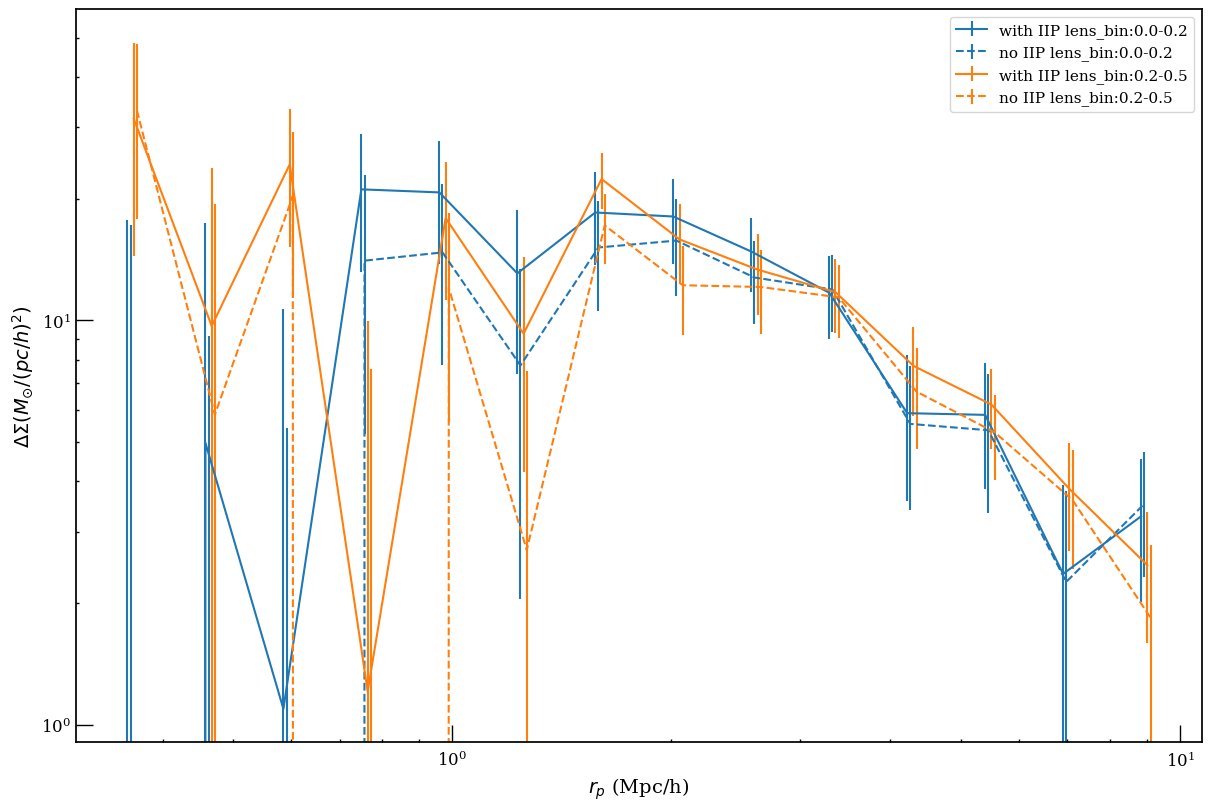

In [34]:
plt.figure(figsize=(12,8))
shift = 1
i=0
for key, result in ds_dict.items():
    color = colors[i // 2 % len(colors)] 
    style = linestyles[i % 2]  
    plt.errorbar(result['rp']*shift, result['ds'], yerr=result['ds_err'], label=key, color=color, linestyle=style)
    shift *= 1.01
    i+=1

plt.yscale('log')
plt.xscale('log')
#plt.xlim([1,15])
plt.ylabel(r'$\Delta\Sigma (M_{\odot}/(pc/h)^2)$')
plt.xlabel(r'$r_p$ (Mpc/h)')
plt.legend()
plt.show()